In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from itertools import product
import matplotlib.pyplot as plt

In [17]:
def Create_dataset(n, m, k):
    X_full, X1_full, X2_full = Create_X(n, n)

    Y_add_full = Create_Y_add(X1_full, X2_full)
    Y_mul_full = Create_Y_mul(X1_full)

    # -----------------
    # TRAIN
    # -----------------
    X_train, X1_train, X2_train = Create_X(n, m)

    Y_add_train = Create_Y_add(X1_train, X2_train)
    Y_mul_train = Create_Y_mul(X1_train)

    # -----------------
    # TEST = full - train
    # -----------------
    X_test, Y_add_test = dataset_difference(
        X_full, Y_add_full,
        X_train, Y_add_train
    )

    _, Y_mul_test = dataset_difference(
        X_full, Y_mul_full,
        X_train, Y_mul_train
    )

    # -----------------
    # 10% TEST -> TRAIN
    # -----------------
    num_extra = int(k * len(X_test))

    # losowe indeksy z testu
    perm = torch.randperm(len(X_test))
    extra_idx = perm[:num_extra]

    # elementy dodawane do train
    X_extra = X_test[extra_idx]
    Y_add_extra = Y_add_test[extra_idx]
    Y_mul_extra = Y_mul_test[extra_idx]

    # dodajemy 10% testu do train
    X_train = torch.cat([X_train, X_extra], dim=0)
    Y_add_train = torch.cat([Y_add_train, Y_add_extra], dim=0)
    Y_mul_train = torch.cat([Y_mul_train, Y_mul_extra], dim=0)

    # usuwamy te elementy z testu
    mask = torch.ones(len(X_test), dtype=torch.bool)
    mask[extra_idx] = False

    X_test = X_test[mask]
    Y_add_test = Y_add_test[mask]
    Y_mul_test = Y_mul_test[mask]

    return X_train, Y_add_train, Y_mul_train, X_test, Y_add_test, Y_mul_test


def Create_X(n, m):
    bits_m = torch.tensor(
        list(product([0, 1], repeat=m)),
        dtype=torch.float32
    )

    # pierwsze n-m bitów = 0
    # ostatnie m bitów = wszystkie kombinacje
    bits_n = torch.cat([
        torch.zeros((2**m, n - m)),
        bits_m
    ], dim=1)

    N = bits_n.shape[0]

    X1 = bits_n.repeat_interleave(N, dim=0)
    X2 = bits_n.repeat(N, 1)

    X = torch.cat((X1, X2), dim=1)

    return X, X1, X2

def dataset_difference(X_full, Y_full, X_subset, Y_subset):
    full = torch.cat([X_full, Y_full], dim=1)
    subset = torch.cat([X_subset, Y_subset], dim=1)

    # dla każdego elementu full sprawdzamy,
    # czy istnieje identyczny element w subset
    mask = torch.ones(len(full), dtype=torch.bool)

    for i in range(len(full)):
        if torch.any(torch.all(full[i] == subset, dim=1)):
            mask[i] = False

    return X_full[mask], Y_full[mask]

def Create_Y_add(X1, X2):
    Y_add = torch.zeros((X1.shape[0], n + 1))
    carry = torch.zeros(X1.shape[0])
    # idziemy od najmłodszego bitu do najstarszego
    for i in range(n - 1, -1, -1):
        s = X1[:, i] + X2[:, i] + carry

        Y_add[:, i + 1] = s % 2
        carry = s // 2
    # końcowe przeniesienie
    Y_add[:, 0] = carry
    return Y_add

def Create_Y_mul(X1):
    Y_mul = torch.zeros((X1.shape[0], n + 1))

    Y_mul[:, :-1] = X1
    
    return Y_mul
    

In [33]:
class MLP(torch.nn.Module):
    # constructor
    def __init__(self, input_size, hidden_sizes, output_size):
        super(MLP, self).__init__()

        self.layer = nn.ModuleList()
        self.layer.append(nn.Linear(input_size, hidden_sizes[0]))
        for i in range(len(hidden_sizes)-1):
            self.layer.append(nn.Linear(hidden_sizes[i], hidden_sizes[i+1]))
        self.layer.append(nn.Linear(hidden_sizes[-1], output_size))
        
        self.activation = nn.Sigmoid()
    # mathod called once the model is executed
    def forward(self, x):
        for i in range(len(self.layer)):
            x = self.layer[i](x)
            x = self.activation(x)
        return x

def TrainModel(N_epochs, model, X, Y, X_test, Y_test, lr):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    MSE = nn.MSELoss()
    train_loss = []
    test_loss = []
    model.train()
    for _ in range(N_epochs):
        # this will zero out the gradients for this batch
        optimizer.zero_grad()
        # make predictions
        y_pred = model(X)
        y_pred_test = model(X_test)
        # calculate the MSE loss
        loss = MSE(y_pred, Y)
        loss_test = MSE(y_pred_test, Y_test)
        # backpropagate the loss
        loss.backward()
        # update the model weights (with assumed learning rate)
        optimizer.step()
        train_loss.append(loss.item())
        test_loss.append(loss_test.item())
    print("last loss value = ", train_loss[-1])
    print()
    plt.plot(range(1, len(train_loss) + 1), train_loss, label="Train loss")
    plt.plot(range(1, len(train_loss) + 1), test_loss, label="Test loss")

    plt.yscale("log")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.legend()
    plt.grid(True, which="both")
    plt.show()
    return train_loss, test_loss, model

def TestModel(model, X, Y):
    model.eval()
    MSE = nn.MSELoss()

    with torch.no_grad():
        Y_pred = model(X)

    print("test loss = ", MSE(Y_pred, Y).item())

    for i in range(len(X)):
        correct_prob = torch.where(
            Y[i] == 1,
            Y_pred[i],
            1 - Y_pred[i]
        )

        print(f"X1:      {X[i, :n].int().tolist()}")
        print(f"X2:      {X[i, n:].int().tolist()}")
        print(f"Y:       {Y[i].int().tolist()}")
        print(f"Y_pred:  {[f'{x:.2f}' for x in Y_pred[i].tolist()]}")
        print()
    

rozmiar ds train =  54 rozmiar ds test =  10
last loss value =  2.809706074913265e-06



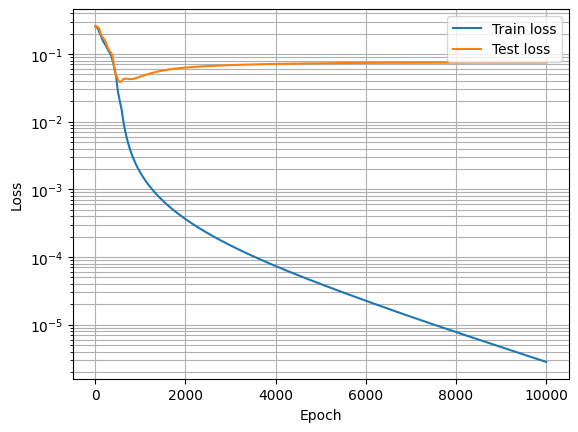

test loss =  0.07462012022733688
X1:      [0, 0, 0]
X2:      [1, 0, 1]
Y:       [0, 1, 0, 1]
Y_pred:  ['0.00', '1.00', '0.00', '1.00']

X1:      [0, 1, 0]
X2:      [1, 0, 0]
Y:       [0, 1, 1, 0]
Y_pred:  ['0.00', '1.00', '1.00', '0.00']

X1:      [0, 1, 0]
X2:      [1, 1, 1]
Y:       [1, 0, 0, 1]
Y_pred:  ['1.00', '0.00', '0.00', '1.00']

X1:      [0, 1, 1]
X2:      [1, 0, 0]
Y:       [0, 1, 1, 1]
Y_pred:  ['0.00', '1.00', '1.00', '1.00']

X1:      [0, 1, 1]
X2:      [1, 1, 0]
Y:       [1, 0, 0, 1]
Y_pred:  ['1.00', '0.00', '0.00', '1.00']

X1:      [1, 0, 1]
X2:      [0, 0, 0]
Y:       [0, 1, 0, 1]
Y_pred:  ['0.00', '1.00', '0.00', '1.00']

X1:      [1, 1, 0]
X2:      [0, 0, 0]
Y:       [0, 1, 1, 0]
Y_pred:  ['0.00', '1.00', '1.00', '0.00']

X1:      [1, 1, 0]
X2:      [1, 0, 1]
Y:       [1, 0, 1, 1]
Y_pred:  ['1.00', '0.00', '1.00', '1.00']

X1:      [1, 1, 1]
X2:      [0, 1, 1]
Y:       [1, 0, 1, 0]
Y_pred:  ['1.00', '1.00', '0.00', '0.00']

X1:      [1, 1, 1]
X2:      [1, 1, 1]
Y:

In [37]:
TrainAdding = True

n = 3 #all input bits
m = 2 #trained input bits
k = 0.8 #additional elements from test ds moved to train ds

X_train, Y_add_train, Y_mul_train, X_test, Y_add_test, Y_mul_test = Create_dataset(n, m, k)

print("rozmiar ds train = ", len(X_train), "rozmiar ds test = ", len(X_test))

# define model and learnig scheme
model = MLP(input_size=2*n, hidden_sizes=[3*n, 3*n], output_size=n+1)

# train
Epochs = 10000
lr = 1e-2
if TrainAdding == True:
    loss, test_loss, model = TrainModel(Epochs, model, X_train, Y_add_train, X_test, Y_add_test, lr)
    TestModel(model, X_test, Y_add_test)
    TestModel(model, X_train, Y_add_train)
else:
    loss, test_loss, model = TrainModel(Epochs, model, X_train, Y_mul_train, X_test, Y_mul_test, lr)
    TestModel(model, X_test, Y_mul_test)
    TestModel(model, X_train, Y_mul_train)